# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

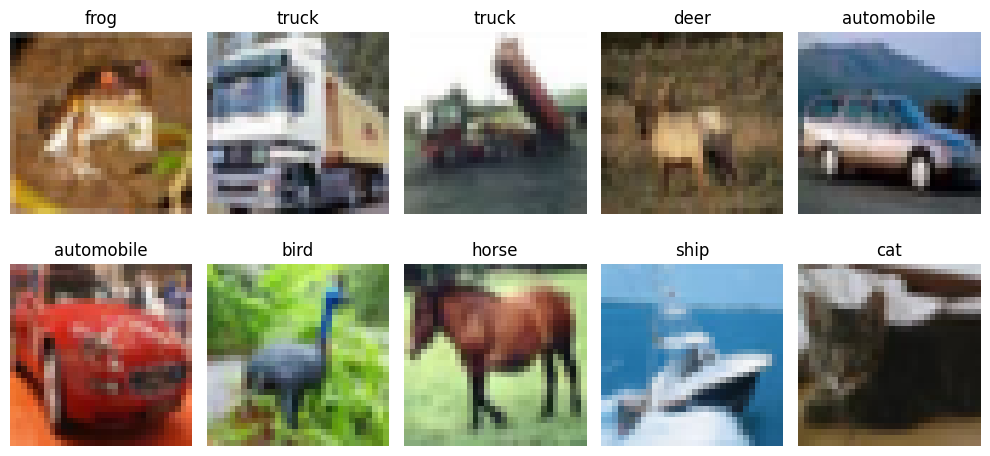

In [20]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [21]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [23]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.2427 - loss: 2.0447 - val_accuracy: 0.3066 - val_loss: 1.9311
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.2913 - loss: 1.9231 - val_accuracy: 0.3270 - val_loss: 1.8680
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3091 - loss: 1.8770 - val_accuracy: 0.3566 - val_loss: 1.8329
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3260 - loss: 1.8448 - val_accuracy: 0.3530 - val_loss: 1.8351
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.3219 - loss: 1.8396 - val_accuracy: 0.3726 - val_loss: 1.8043
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.3329 - loss: 1.8207 - val_accuracy: 0.3746 - val_loss: 1.7829
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.3420 - loss: 1.7964 - val_accuracy: 0.3834 - val_loss: 1.7727
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.3471 - loss: 1.7812 - 

In [24]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4323 - loss: 1.6461
ANN Test Accuracy: 0.43230000138282776


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [25]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 80ms/step - accuracy: 0.4645 - loss: 1.4996 - val_accuracy: 0.4216 - val_loss: 1.6332
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.6036 - loss: 1.1300 - val_accuracy: 0.5818 - val_loss: 1.1855
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6686 - loss: 0.9551 - val_accuracy: 0.6372 - val_loss: 1.0735
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.7140 - loss: 0.8262 - val_accuracy: 0.6102 - val_loss: 1.1330
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 82ms/step - accuracy: 0.7451 - loss: 0.7330 - val_accuracy: 0.6914 - val_loss: 0.9092
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7731 - loss: 0.6481 - val_accuracy: 0.6872 - val_loss: 0.9511
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.7975 - loss: 0.5818 - val_accuracy: 0.7366 - val_loss: 0.8085
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.8141 - loss: 0.5266 - 

In [26]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7242 - loss: 0.8457
CNN Test Accuracy: 0.7242000102996826


## 📈 Compare Learning Curves

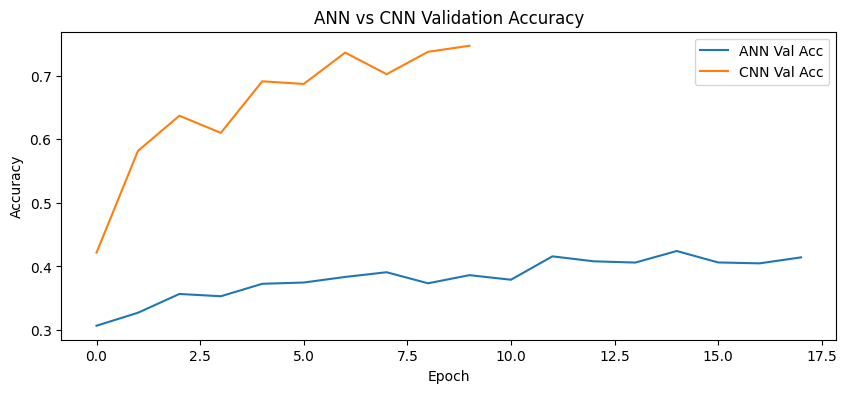

In [27]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [29]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[early_stop])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.3646 - loss: 1.7324 - val_accuracy: 0.4748 - val_loss: 1.4810
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.4652 - loss: 1.4821 - val_accuracy: 0.5146 - val_loss: 1.3458
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.5037 - loss: 1.3892 - val_accuracy: 0.5708 - val_loss: 1.1819


In [31]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4632 - loss: 1.4872
Augmented CNN Accuracy: 0.46320000290870667


# 📊 Final Comparison Table

In [32]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4323
1,CNN,0.7242
2,CNN + Augmentation,0.4632


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**